In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

radiology_data = pd.read_csv("RadioLens.csv")

radiology_data.shape

radiology_data.columns

radiology_data.dtypes

radiology_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient ID           808 non-null    str    
 1   Patient Name         806 non-null    str    
 2   Sex                  806 non-null    str    
 3   Age                  791 non-null    float64
 4   Modality             809 non-null    str    
 5   Procedure            757 non-null    str    
 6   Study Description    808 non-null    str    
 7   Img                  809 non-null    int64  
 8   Hospital             809 non-null    str    
 9   Arrival Date & Time  809 non-null    str    
 10  Referring Physician  216 non-null    str    
dtypes: float64(1), int64(1), str(9)
memory usage: 69.7 KB


In [29]:
radiology_data.isnull().sum()

Patient ID               1
Patient Name             3
Sex                      3
Age                     18
Modality                 0
Procedure               52
Study Description        1
Img                      0
Hospital                 0
Arrival Date & Time      0
Referring Physician    593
dtype: int64

In [31]:
is_null_age = radiology_data["Age"].isnull()
radiology_data[is_null_age]

,Patient ID,Patient Name,Sex,Age,Modality,Procedure,Study Description,Img,Hospital,Arrival Date & Time,Referring Physician
19,26080284,Raiyan,M,NaN,CR,CHEST PA VIEW,CHEST,1,"GREEN DELTA HOSPITAL & LAB, NARAYANGANJ","08/09/2026, 12:43:25 PM",NaN
271,000000000000000000000,NaN,F,NaN,CR,NaN,LOW_EXM,1,"DR. MAHFUZUR RAHMAN LAB, CHAWKBAZAR, CTG","08/05/2026, 07:47:27 PM",NaN
274,02,Mir Hossan---23,M,NaN,CR,NaN,UP_EXM,1,"POPULAR MEDICAL CENTER, DEWANHAT","08/05/2026, 05:31:01 PM",NaN
321,039,Rifat Hossain Said,M,NaN,CR,LUMBO-SACRAL SPINE B/V,PELVIS,1,CHOWDHURY HAT NURSING HOME & DIAGNOSTIC CENTER,"08/04/2026, 01:49:22 PM",NaN
339,V2608250880,Isra,F,NaN,CR,CHEST AP WITH LATERAL VIEW,EMERGENCY,2,VITAL RESEARCH UNIT-1,"08/03/2026, 07:23:32 PM",NaN
341,30112010,Khadija,F,NaN,CR,NaN,PELVISNeeds review,1,BURIRCHANG MEDICAL CENTER & SHEPA HOSPITAL,"08/03/2026, 07:01:59 PM",NaN
342,30112010,Khadija,F,NaN,CR,LUMBO-SACRAL SPINE B/V,LUMBO-SACRAL SPINE B/VNeeds review,1,BURIRCHANG MEDICAL CENTER & SHEPA HOSPITAL,"08/03/2026, 07:01:59 PM",NaN
471,3852,Mahamuda,F,NaN,CR,CHEST PA VIEW,CHEST,1,"LAB SEVEN HEALTH CARE, CTG","07/30/2026, 03:56:00 PM",NaN
486,1128,Kulsuma Begum -50yes,F,NaN,DX,CHEST PA VIEW,CHEST,1,"HEALTH ICON LAB & CONSULTATION POINT,CTG","07/30/2026, 01:59:40 PM",NaN
488,53089,Baby,M,NaN,DX,KNEE JOINT,KNEE JOINT,2,"DIGITAL HOSPITAL (PVT) LTD, COX'S BAZAR","07/30/2026, 01:53:56 PM",NaN


In [32]:
is_null_age = radiology_data["Age"].isnull()
radiology_data[is_null_age][["Patient ID","Patient Name","Age","Hospital"]]

,Patient ID,Patient Name,Age,Hospital
19,26080284,Raiyan,NaN,"GREEN DELTA HOSPITAL & LAB, NARAYANGANJ"
271,000000000000000000000,NaN,NaN,"DR. MAHFUZUR RAHMAN LAB, CHAWKBAZAR, CTG"
274,02,Mir Hossan---23,NaN,"POPULAR MEDICAL CENTER, DEWANHAT"
321,039,Rifat Hossain Said,NaN,CHOWDHURY HAT NURSING HOME & DIAGNOSTIC CENTER
339,V2608250880,Isra,NaN,VITAL RESEARCH UNIT-1
341,30112010,Khadija,NaN,BURIRCHANG MEDICAL CENTER & SHEPA HOSPITAL
342,30112010,Khadija,NaN,BURIRCHANG MEDICAL CENTER & SHEPA HOSPITAL
471,3852,Mahamuda,NaN,"LAB SEVEN HEALTH CARE, CTG"
486,1128,Kulsuma Begum -50yes,NaN,"HEALTH ICON LAB & CONSULTATION POINT,CTG"
488,53089,Baby,NaN,"DIGITAL HOSPITAL (PVT) LTD, COX'S BAZAR"


In [53]:
radiology_data["Hospital"].value_counts().max()
ordering_hospital.index[0]

radiology_data[radiology_data["Hospital"]=="SHEBA GENERAL HOSPITAL & DIGITAL DIAGNOSTIC COMPLEX, SONARGAON, NARAYANGANJ"]

np.int64(173)

In [64]:

hospital_count = radiology_data["Hospital"].value_counts()
top_hospital = radiology_data[radiology_data["Hospital"]==hospital_count.index[0]]
print(top_hospital)

    Patient ID  Patient Name Sex   Age Modality  \
77      124634    ABDUL KAFI   M  62.0       DX   
78      124634    ABDUL KAFI   M  62.0       DX   
79      124634    ABDUL KAFI   M  62.0       DX   
80      124634    ABDUL KAFI   M  62.0       DX   
81      124634    ABDUL KAFI   M  62.0       DX   
..         ...           ...  ..   ...      ...   
245     124634    ABDUL KAFI   M  62.0       DX   
246     124634    ABDUL KAFI   M  62.0       DX   
390     124293  Shefali Rani   F  71.0       DX   
712     122822  Osimun Nessa   F  94.0       DX   
713     122822  Osimun Nessa   F  94.0       DX   

                           Procedure                Study Description  Img  \
77                        THYROID BV                       THYROID BV    1   
78                       MASTOID T/V                      MASTOID T/V    1   
79                SACRO-COCCYX JOINT               SACRO-COCCYX JOINT    1   
80                         HEEL LEFT                        HEEL LEFT    1 

In [65]:
top_hospital["Modality"].value_counts()

Modality
DX    173
Name: count, dtype: int64

In [66]:
top_hospital["Age"].mean()

np.float64(62.421965317919074)

In [67]:
top_hospital["Sex"].value_counts()

Sex
M    170
F      3
Name: count, dtype: int64

In [69]:
radiology_data.groupby("Hospital")["Age"].mean()

Hospital
ADOR HOSPITAL LTD, NOAKHALI                    40.000000
AL-AFIYAH HOSPITAL & DIAGNOSTIC CENTER LTD.    63.000000
AL-HERA CLINIC, CHAPAI NAWABGONJ               24.000000
AL-MADINA CLINIC, ROHANPUR, CHAPAI             68.000000
AL-MADINA DIAGNOSTIC CENTER, BARODI            71.000000
                                                 ...    
ULTRA ASSAY HEALTH CARE, PAHARTOLI             30.000000
VITAL RESEARCH UNIT-1                          32.720588
VITAL RESEARCH UNIT-2                          36.500000
WELFARE DIAGNOSTIC CENTER,B-HAT                52.000000
ZABA MEDICAL CENTER, CHATAK                    67.500000
Name: Age, Length: 125, dtype: float64

In [71]:
radiology_data.groupby("Hospital").agg({
    "Age": "mean",
    "Patient ID": "count"
})

,Age,Patient ID
Hospital,,
"ADOR HOSPITAL LTD, NOAKHALI",40.000000,1
AL-AFIYAH HOSPITAL & DIAGNOSTIC CENTER LTD.,63.000000,1
"AL-HERA CLINIC, CHAPAI NAWABGONJ",24.000000,1
"AL-MADINA CLINIC, ROHANPUR, CHAPAI",68.000000,1
"AL-MADINA DIAGNOSTIC CENTER, BARODI",71.000000,2
...,...,...
"ULTRA ASSAY HEALTH CARE, PAHARTOLI",30.000000,3
VITAL RESEARCH UNIT-1,32.720588,71
VITAL RESEARCH UNIT-2,36.500000,2


In [72]:
result = radiology_data.groupby("Hospital").agg({
    "Age": "mean",
    "Patient ID": "count"
})

result.sort_values(by="Patient ID", ascending=False)

,Age,Patient ID
Hospital,,
"SHEBA GENERAL HOSPITAL & DIGITAL DIAGNOSTIC COMPLEX, SONARGAON, NARAYANGANJ",62.421965,173
EPIC HEALTH CARE LTD. UNIT-2,44.959459,74
VITAL RESEARCH UNIT-1,32.720588,71
"DOCTOR'S POINT, FENI",40.454545,56
NATIONAL HOSPITAL & SIGMA LAB LTD. (CT & MRI),50.348837,43
...,...,...
"S A DIAGNOSTIC CENTER, FENI",75.000000,1
"TALUKDAR HOSPITAL & DIAGNOSTIC CENTER, NANDINA",18.000000,1
TEST Easy,10.000000,1


In [73]:
radiology_data.groupby("Hospital").agg({
    "Patient ID": "count",
    "Age": ["mean", "min", "max"]
})

Patient ID        Age            
                                                 count       mean   min   max
Hospital                                                                     
ADOR HOSPITAL LTD, NOAKHALI                          1  40.000000  40.0  40.0
AL-AFIYAH HOSPITAL & DIAGNOSTIC CENTER LTD.          1  63.000000  63.0  63.0
AL-HERA CLINIC, CHAPAI NAWABGONJ                     1  24.000000  24.0  24.0
AL-MADINA CLINIC, ROHANPUR, CHAPAI                   1  68.000000  68.0  68.0
AL-MADINA DIAGNOSTIC CENTER, BARODI                  2  71.000000  70.0  72.0
...                                                ...        ...   ...   ...
ULTRA ASSAY HEALTH CARE, PAHARTOLI                   3  30.000000   2.0  45.0
VITAL RESEARCH UNIT-1                               71  32.720588   0.0  85.0
VITAL RESEARCH UNIT-2                                2  36.500000  15.0  58.0
WELFARE DIAGNOSTIC CENTER,B-HAT                      2  52.000000  39.0  65.0
ZABA MEDICAL CENTER, CHATAK                          2  67.500000  65.0  70.0

[125 rows x 4 columns]

In [77]:
procedure_data = radiology_data["Procedure"].value_counts()
procedure_data.head(5)

Procedure
CHEST PA VIEW             103
WHOLE ABDOMEN              38
LUMBO-SACRAL SPINE B/V     33
BRAIN / HEAD               32
CHEST                      18
Name: count, dtype: int64

In [81]:
radiology_data.groupby(["Procedure", "Modality"]).size()

Procedure                    Modality
ABDOMEN AP (SUPINE)          CR          1
                             DX          2
ABDOMEN E/P                  CR          6
                             DX          1
ANKLE JOINT BOTH             DX          2
                                        ..
WRIST JOINT RIGHT            CR          5
                             DX          4
WRIST JOINT WITH HAND LEFT   CR          2
                             DX          1
WRIST JOINT WITH HAND RIGHT  DX          1
Length: 267, dtype: int64

In [87]:
hospital_modality = radiology_data.groupby(["Hospital","Modality"]).size()
hospital_modality.sort_values(ascending=False).head(10)

Hospital                                                                     Modality
SHEBA GENERAL HOSPITAL & DIGITAL DIAGNOSTIC COMPLEX, SONARGAON, NARAYANGANJ  DX          173
VITAL RESEARCH UNIT-1                                                        CR           71
DOCTOR'S POINT, FENI                                                         DX           56
EPIC HEALTH CARE LTD. UNIT-2                                                 CT           54
NATIONAL HOSPITAL & SIGMA LAB LTD. (CT & MRI)                                CT           32
ORBIT DIAGNOSTIC CENTRE, KUMIRA, CTG                                         DX           29
EPIC HEALTH CARE LTD. UNIT-2                                                 MR           20
EPIC HEALTH CARE LTD. MAIN BRANCH                                            CT           20
FENI MEDICAL CENTER                                                          DX           20
CHANDER HASHI HOSPITAL LTD (UNIT-1)                                          

In [88]:
radiology_data.corr(numeric_only=True)

,Age,Img
Age,1.000000,0.092041
Img,0.092041,1.000000


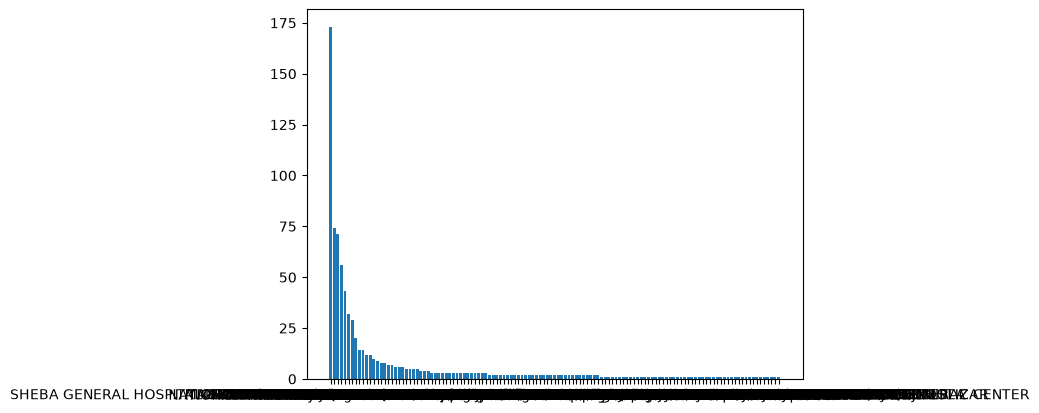

In [91]:


hospital_counts = radiology_data["Hospital"].value_counts()

plt.bar(hospital_counts.index, hospital_counts.values)
plt.show()

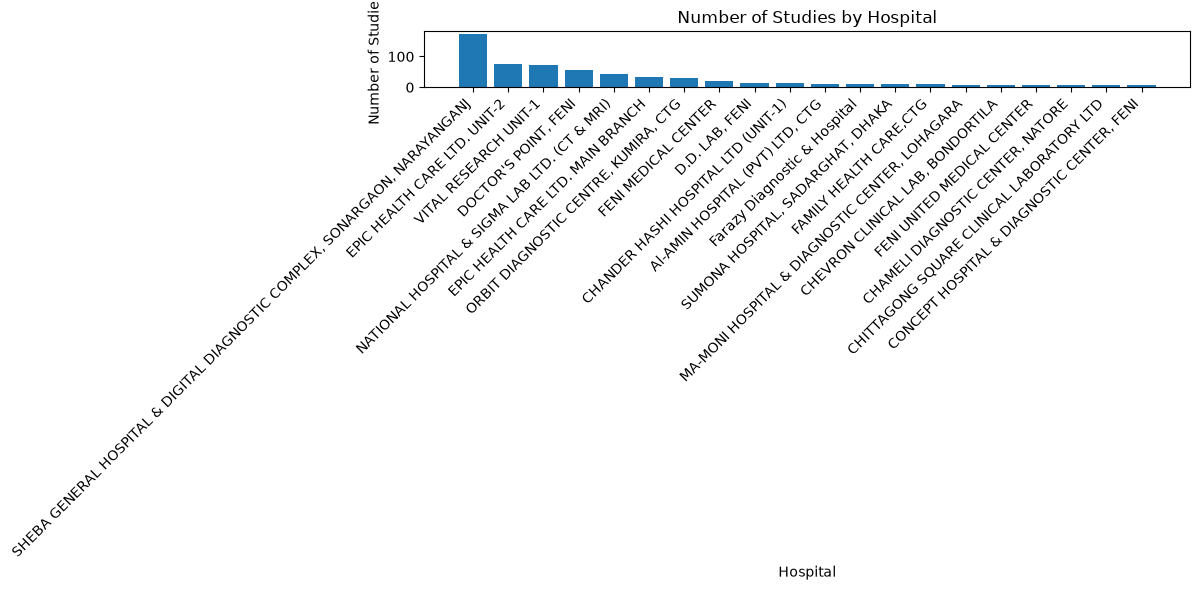

In [94]:

hospital_counts = radiology_data["Hospital"].value_counts().head(20)

plt.figure(figsize=(12, 6))

plt.bar(hospital_counts.index, hospital_counts.values)

plt.title("Number of Studies by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Number of Studies")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()